# <center><u>**Hypothesis Testing**</u></center>
<figure style="text-align:center;">
    <img src="notebook_images/hypothesis_testing/hypothesis_testing.jpg" alt="Hypothesis Testing">
</figure>

---

---

---

## DATASETS
- used in notebook:
    - [Late Shipments](https://assets.datacamp.com/production/repositories/5982/datasets/887ec4bc2bcfd4195e7d3ad113168555f36d3afa/late_shipments.feather)
    - [US Democrat POTUS Votes 12/16](https://assets.datacamp.com/production/repositories/5982/datasets/4ab6431d773d1fe659ac120b4b49a1b525a76712/dem_votes_potus_12_16.feather)
- other datasets to practice:
    - [Stack Overflow](https://assets.datacamp.com/production/repositories/5982/datasets/c59033b93930652f402e30db77c3b8ef713dd701/stack_overflow.feather)
    - [US Republican POTUS Votes 08/12](https://assets.datacamp.com/production/repositories/5982/datasets/7e3351ff263f77755c046c79d5ff855f4de3307e/repub_votes_potus_08_12.feather)

### IMPORTS

In [44]:
import pandas as pd

import numpy as np
from scipy.stats import norm, t, chisquare
import pingouin
from statsmodels.stats.proportion import proportions_ztest

import matplotlib.pyplot as plt
import seaborn as sns

---

### INITIAL DATA LOAD AND VIEWING
- load `late_shipments.feather` into DataFrame
- load `dem_votes_potus_12_16.feather` into DataFrame
- show `.head(33)` of each loaded DataFrame

In [13]:
ship_df = pd.read_feather('~/000_Duckspace/Learning/DataScience/Python_DataScience_Examples/data/hypothesis_testing/late_shipments.feather')

In [3]:
sample_dem_data = pd.read_feather('~/000_Duckspace/Learning/DataScience/Python_DataScience_Examples/data/hypothesis_testing/dem_votes_potus_12_16.feather')

In [10]:
ship_df.head(33)

,id,country,managed_by,fulfill_via,vendor_inco_term,shipment_mode,late_delivery,late,product_group,sub_classification,...,line_item_quantity,line_item_value,pack_price,unit_price,manufacturing_site,first_line_designation,weight_kilograms,freight_cost_usd,freight_cost_groups,line_item_insurance_usd
0,36203.0,Nigeria,PMO - US,Direct Drop,EXW,Air,1.0,Yes,HRDT,HIV test,...,2996.0,266644.00,89.00,0.89,"Alere Medical Co., Ltd.",Yes,1426.0,33279.83,expensive,373.83
1,30998.0,Botswana,PMO - US,Direct Drop,EXW,Air,0.0,No,HRDT,HIV test,...,25.0,800.00,32.00,1.60,"Trinity Biotech, Plc",Yes,10.0,559.89,reasonable,1.72
2,69871.0,Vietnam,PMO - US,Direct Drop,EXW,Air,0.0,No,ARV,Adult,...,22925.0,110040.00,4.80,0.08,Hetero Unit III Hyderabad IN,Yes,3723.0,19056.13,expensive,181.57
3,17648.0,South Africa,PMO - US,Direct Drop,DDP,Ocean,0.0,No,ARV,Adult,...,152535.0,361507.95,2.37,0.04,"Aurobindo Unit III, India",Yes,7698.0,11372.23,expensive,779.41
4,5647.0,Uganda,PMO - US,Direct Drop,EXW,Air,0.0,No,HRDT,HIV test - Ancillary,...,850.0,8.50,0.01,0.00,Inverness Japan,Yes,56.0,360.00,reasonable,0.01
5,4648.0,Ethiopia,PMO - US,Direct Drop,EXW,Air,0.0,No,HRDT,HIV test,...,7002.0,161046.00,23.00,23.00,"KHB Test Kit Facility, Shanghai China",Yes,5057.0,44360.44,expensive,315.65
6,29061.0,Sudan,PMO - US,Direct Drop,EXW,Air,0.0,No,HRDT,HIV test,...,70.0,6230.00,89.00,0.89,"Alere Medical Co., Ltd.",Yes,33.0,1255.77,reasonable,10.28
7,2647.0,Cote d'Ivoire,PMO - US,Direct Drop,EXW,Air,0.0,No,HRDT,HIV test,...,100.0,7535.00,75.35,1.88,Bio-Rad Laboratories,Yes,107.0,1845.74,reasonable,NaN
8,23070.0,Malawi,PMO - US,Direct Drop,EXW,Air,0.0,No,HRDT,HIV test,...,32.0,1024.00,32.00,1.60,"Trinity Biotech, Plc",Yes,17.0,703.25,reasonable,1.27
9,22069.0,Uganda,PMO - US,Direct Drop,EXW,Air,0.0,No,ARV,Adult,...,50000.0,162000.00,3.24,0.11,"Cipla, Goa, India",Yes,5593.0,19759.68,expensive,200.39


In [11]:
sample_dem_data.head(33)

,state,county,dem_percent_12,dem_percent_16
0,Alabama,Bullock,76.305900,74.946921
1,Alabama,Chilton,19.453671,15.847352
2,Alabama,Clay,26.673672,18.674517
3,Alabama,Cullman,14.661752,10.028252
4,Alabama,Escambia,36.915731,31.020546
5,Alabama,Fayette,22.866851,16.511092
6,Alabama,Franklin,29.201584,18.247508
7,Alabama,Hale,62.605577,59.390547
8,Alabama,Lamar,22.969579,14.872237
9,Alabama,Lauderdale,33.883111,25.179001


---

---

---

## SAMPLE MEAN

### &nbsp;&nbsp;&nbsp;&nbsp; •**Exercise**

---
- calculate the proportion of late shipments in the dataset's `'late'` column, where `"Yes"` is a late shipment
- print answer as a percentage

In [4]:
prop_late = (ship_df['late'] == "Yes").mean()
print(f'{prop_late * 100}%')

6.1%


---

## Z-SCORE
- since the sampled mean was $\approx 6.0%$, set `0.06` as the hypothesized value and call it `prop_late_hyp`
- use some method of loading `late_shipment_bootstrap_distribution.csv`as a list called `late_shipments_boot_distn`
    - (hint: it has no header and is written as a single column of floats)
    - this file contains a bootstrapped sample of `late_shipment.feather`
- calculate the standard error of `late_shipments_boot_distn` using `np.std( )` with `ddof=1`and call it `std_error`
- calculate the z-score by substraction `prop_late_hyp` from `prop_late` (calculated above), then dividing this by `std_error` and call it `z-score`
- print `z-score`

### &nbsp;&nbsp;&nbsp;&nbsp; •**Exercise**

---

In [5]:
prop_late_hyp = 0.06
_df = pd.read_csv('/home/wanderduck/000_Duckspace/Learning/DataScience/Python_DataScience_Examples/data/hypothesis_testing/late_shipment_bootstrap_distribution.csv', header=None)
late_ship_boot_distn = _df[0].tolist()
std_error = np.std(late_ship_boot_distn, ddof=1)
z_score = ( prop_late - prop_late_hyp) / std_error
print(f'z-score: {z_score}')

z-score: 0.13353771933071554


---

## HYPOTHESIS AND HYPOTHESIS TESTING
- A hypothesis is a statement about an unknown population parameter
- A hypothesis test is a test of two competing hypotheses
- The null hypothesis ($H_0$) is the existing idea
- The alternative hypothesis ($H_A$) is the new "challenger" idea of the researcher
- Either $H_A$ or H is true (not both)
- Initially, $H_0$ is assumed to be true
- The test ends in either "reject $H_0$ " or "fail to reject $H_0$ "
- If the evidence from the sample is "significant" that $H_A$ is true, reject $H_0$ , else choose $H_0$
- *Significance level* is "beyond a reasonable doubt" for hypothesis testing
- Hypothesis tests check if the sample statistics lie in the tails of the null distribution

Test | Tails
:---: | :---:
alternative *different* from *null* | two-tailed
alternative *greater* than *null* | right-tailed
alternative *less* than *null* | left-tailed

<figure>
    <img src="notebook_images/hypothesis_testing/distribution_plot.png" width="33%">
</figure>

---

## P-VALUES
- **p-values**: probability of obtaining a result, assuming the *null hypothesis* is *true*
    - Large p-value = strong support for $H_0$
    - Small p-value = strong evidence against $H_0$
        - "*small*" means "close to zero"

### &nbsp;&nbsp;&nbsp;&nbsp; •**Exercise**

---
- calculate the `z_score`of `prop_late`
- to calculate the `p_value` subtract `norm.cdf(z-score, loc=0, scale=1)` from `1`

In [6]:
z_score = ( prop_late - prop_late_hyp) / std_error
p_value = 1 - norm.cdf(z_score, loc=0, scale=1)
print(p_value)

0.4468840678346485


## STATISICAL SIGNIFICANCE
- The *significance level* of a hypothesis test ($\alpha$) is the threshold point for "beyond a reasonable doubt"
- Common values of $\alpha$ are `0.2`, `0.1`, `0.05`, and `0.01`
- if $p \leq \alpha$, reject $H_0$, else fail to reject $H_0$
- **$\alpha$ should be set *<u>prior</u>* to conducting hypothesis testing**

### &nbsp;&nbsp;&nbsp;&nbsp; •**Exercise**

---
- calculate a `95%` confidence interval using the quantile method (`np.quantile()`) of `late_ship_boot_distn`

In [7]:
lower = np.quantile(late_ship_boot_distn, 0.025)
upper = np.quantile(late_ship_boot_distn, 0.975)
print(f'lower: {lower}, upper: {upper}, hypothesis: {prop_late_hyp} ')

lower: 0.047, upper: 0.076, hypothesis: 0.06 


- `p_value` is greater than $\alpha$ and `late_ship_hyp` of `0.06` falls within the confidence interval of `0.047` and `0.076`

---

## TYPES OF ERRORS

 Chosen Outcome |  $H_0$ actual | $H_A$ actual
 :----: | :----: | :----:
 $H_0$ chosen | correct | false negative (Type II)
 $H_A$ chosen | false positive (Type I) | correct

- *false positives* are *Type I* errors; *false negatives* are *Type II* errors

---

## PERFORMING T-TESTS

- let's say you are trying to determine whether the weight of late shipments were **greater than** the weight of on-time shipments
- you can calculate *test statistics* to help you determine this
    - $H_0$: $\mu_{0}$ = $\mu_{A}$
- in this, **$H_0$**: the weight is **the same** for on-time and late shipments
- $H_0$: $\mu_{weight-ontime}$ = $\mu_{late}$
- $\bar x$: sample mean
- $\bar x_{0} - \bar x_{A}$ is a test statistics, and `z-score` is a type of standardized test statistic
- For our hypothesis:  $\bar x_{weight-ontime} - \bar x_{weight-late}$
- $ z = \dfrac{sample\,stat - population\,parameter}{standard\,error}$
- $ t = \dfrac{\Delta\,sample\,stats - \Delta\,population\,parameter}{standard\,error}$
- the t equation can be rewritten: $t=\dfrac{\bar x_{0}-\bar x_{A}}{\sqrt{\dfrac{s_{0}^2}{n_{0}}+ \dfrac{s_{A}^2}{n_{A}}}}$
    - where:
        - $s$ = standard deviation of the variable
        - $n$ = sample size (number of observations/rows in sample)
- for our example: $t=\dfrac{\bar x_{weight-ontime}-\bar x_{weight-late}}{\sqrt{\dfrac{s_{weight-ontime}^2}{n_{weight-ontime}}+ \dfrac{s_{weight-late}^2}{n_{weight-late}}}}$


### &nbsp;&nbsp;&nbsp;&nbsp; •**Exercise**

---

In [8]:
x_bar = ship_df.groupby('late')['weight_kilograms'].mean()
xbar_yes = x_bar['Yes'] #weight-late
xbar_no = x_bar['No'] #weight-ontime

s = ship_df.groupby('late')['weight_kilograms'].std()
s_yes = s['Yes']
s_no = s['No']

n = ship_df.groupby('late')['weight_kilograms'].count()
n_yes = n['Yes']
n_no = n['No']

numerator = xbar_no - xbar_yes
denominator = np.sqrt((s_no ** 2 / n_no) + (s_yes ** 2 / n_yes))

t_stat = numerator / denominator

print(f't-statatistic: {t_stat}')

t-statatistic: -2.3936661778766433


## CALCULATING P-VALUE FROM T-STATISTIC
- t-statistics follow a t-distribution
- t-distributions have a parameter called *degrees of freedom* or *df*
- t-distributions look like normal distributions with flatter tails

![t-distribution](notebook_images/hypothesis_testing/t-distribution_plot.png)

- Larger degrees of freedom → t-distribution gets closer to the normal distribution
- Normal distribution → t-distribution with infinite df
- **Degrees of freedom**: maximum number of logically independent values in the data sample

![t-distribution up to df=8](notebook_images/hypothesis_testing/t-distribution_df-to-8_plot.png)

- degrees of freedom: $df = n_0 + n_A -2$

- If testing $H_0 > H_A$, use right-tailed test
- If testing $H_0 < H_A$, use left-tailed test
- Right-tailed test:
    - `p-value = 1 - t.cdf(t_stat, df=degrees_of_freedom)`
    - `p-value = t.sf(t_stat, df=degrees_of_freedom)`
- Left-tailed test:
    - `p-value = t.cdf(t_stat, df=degrees_of_freedom)`

### &nbsp;&nbsp;&nbsp;&nbsp; •**Exercise**

---
- We are testing:
    - $H_0$: the mean weight of on-time shipments is *equal to* the mean weight of late shipments
    - $H_A$: the mean weight of on-time shipments is *less than* the mean weight of late shipments
    - so use a left-tailed test
- let $\alpha = 0.05$
- If $p \leq \alpha$, then reject $H_0$

In [9]:
alpha = 0.05

x_bar = ship_df.groupby('late')['weight_kilograms'].mean()
xbar_yes = x_bar['Yes']
xbar_no = x_bar['No']

s = ship_df.groupby('late')['weight_kilograms'].std()
s_yes = s['Yes']
s_no = s['No']

n = ship_df.groupby('late')['weight_kilograms'].count()
n_yes = n['Yes']
n_no = n['No']

numerator = xbar_no - xbar_yes
denominator = np.sqrt((s_no ** 2 / n_no) + (s_yes ** 2 / n_yes))

t_stat = numerator / denominator

degrees_of_freedom = (n_yes + n_no) - 2

p = t.cdf(t_stat, df=degrees_of_freedom)

if p <= alpha:
    print(f'Reject H_0: p-value <= alpha\np-value={p: .3g}\nalpha={alpha}')
else:
    print(f'Accept H_0: p-value >= alpha\np-value={p: .3g}\nalpha={alpha}')

Reject H_0: p-value <= alpha
p-value= 0.00843
alpha=0.05


## PAIRED T-TESTS



### &nbsp;&nbsp;&nbsp;&nbsp; •**Exercise**

---
- create `sample_dem_data['diff']` column by subtracting the `dem_percent_12` and `dem_percent_16` columns
- create a histogram of the new column with `bins=20`

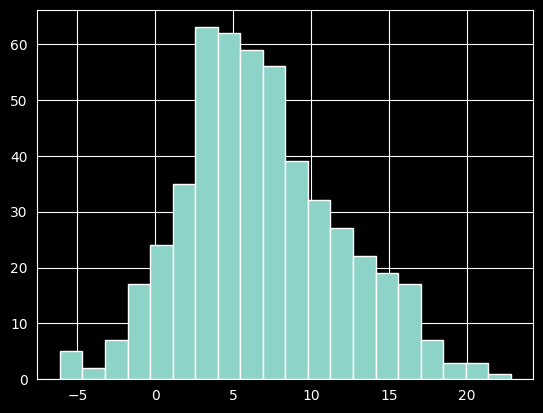

In [19]:
sample_dem_data['diff'] = sample_dem_data['dem_percent_12'] - sample_dem_data['dem_percent_16']
sample_dem_data['diff'].hist(bins=20)
plt.show()

### &nbsp;&nbsp;&nbsp;&nbsp; •**Exercise**

---
- do the "manual" calculation of a paired t-test
- use `pingouin.ttest()` to calculate a pair t-test

In [34]:
# "manual" calculation
x_bar_diff = sample_dem_data['diff'].mean()
s_diff = sample_dem_data['diff'].std(ddof=1)
n_diff = len(sample_dem_data['diff'])

t_stat_diff = (x_bar_diff -0) / np.sqrt((s_diff ** 2) / n_diff)
degrees_of_freedom_diff = n_diff - 1

p_value_diff = 2 * (t.sf(np.abs(t_stat_diff), df=degrees_of_freedom_diff))

# ttest with 'diff' column
ping_ttest = pingouin.ttest(x=sample_dem_data['diff'], y=0, alternative='two-sided')
# paired ttest
ping_ttest_paired = pingouin.ttest(x=sample_dem_data['dem_percent_12'], y=sample_dem_data['dem_percent_16'], paired=True, alternative='two-sided')

print(f'p_value_diff: {p_value_diff}\n-------------\nping_ttest: {ping_ttest}\n-------------\nping_ttest_paired: {ping_ttest_paired}')

p_value_diff: 3.600633979084328e-115
-------------
ping_ttest:                 T  dof alternative          p_val          CI95   cohen_d  \
T_test  30.298384  499   two-sided  3.600634e-115  [6.39, 7.27]  1.354985   

        power        BF10  
T_test    1.0  2.246e+111  
-------------
ping_ttest_paired:                 T  dof alternative          p_val          CI95   cohen_d  \
T_test  30.298384  499   two-sided  3.600634e-115  [6.39, 7.27]  0.454202   

        power        BF10  
T_test    1.0  2.246e+111  


---

## ANALYSIS OF VARIANCE (ANOVA)


### &nbsp;&nbsp;&nbsp;&nbsp; •**Exercise**

---

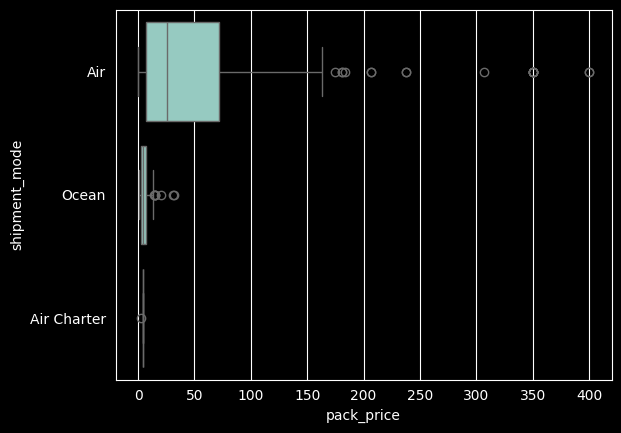

shipment_mode
Air            39.712395
Air Charter     4.226667
Ocean           6.432273
Name: pack_price, dtype: float64
shipment_mode
Air            48.932861
Air Charter     0.992969
Ocean           5.303047
Name: pack_price, dtype: float64


In [40]:
xbar_pack_by_mode = ship_df.groupby('shipment_mode')['pack_price'].mean()
s_pack_by_mode = ship_df.groupby('shipment_mode')['pack_price'].std()
sns.boxplot(x='pack_price', y='shipment_mode', data=ship_df)
plt.show()
print(f'{xbar_pack_by_mode}\n{s_pack_by_mode}')

### &nbsp;&nbsp;&nbsp;&nbsp; •**Exercise**

---
- run an ANOVA test on the hypothesis:
    - $H_0$: Pack prices for every category of shipment mode are the same
    - $H_A$: Pack prices for some categories of shipment mode are different
- use $\alpha = 0.1$

In [45]:
alpha = 0.1
anova_results = pingouin.anova(data=ship_df, dv='pack_price', between='shipment_mode')
print(anova_results)
if anova_results['p_unc'].values[0] <= alpha:
    print('Reject H_0')
else:
    print('Accept H_0')

          Source  ddof1  ddof2        F         p_unc       np2
0  shipment_mode      2    997  21.8646  5.089479e-10  0.042018
Reject H_0


---

## PAIRWISE T-TESTS
- `padjust` methods are:
    - `'none'`: no correction
    - `'bonf'`: one-step Bonferroni correction
   - `'sidak'`: one-step Sidak correction
   - `'holm'`: step-down method using Bonferroni adjustments
   - `'fdr_bh'`: Benjamini/Hochberg FDR correction
   - `'fdr_by'`: Benjamini/Yekutieli FDR correction


### &nbsp;&nbsp;&nbsp;&nbsp; •**Exercise**

---
- repeat the ANOVA test as a pairwise test with both `padjust='none'` and `padjust='bonf'`

In [47]:
pairwise_noc = pingouin.pairwise_tests(data=ship_df, dv='pack_price', between='shipment_mode', padjust='none')
pairwise_bonfc = pingouin.pairwise_tests(data=ship_df, dv='pack_price', between='shipment_mode', padjust='bonf')

print(f'{pairwise_noc}\n-----------------------\n{pairwise_bonfc}')

        Contrast            A            B  Paired  Parametric          T  \
0  shipment_mode          Air  Air Charter   False        True  21.179625   
1  shipment_mode          Air        Ocean   False        True  19.335760   
2  shipment_mode  Air Charter        Ocean   False        True  -3.170654   

          dof alternative         p_unc       BF10    hedges  
0  600.685682   two-sided  8.748346e-75  5.809e+76  0.726592  
1  986.979785   two-sided  6.934555e-71  1.129e+67  0.711119  
2   35.615026   two-sided  3.123012e-03     15.277 -0.423775  
-----------------------
        Contrast            A            B  Paired  Parametric          T  \
0  shipment_mode          Air  Air Charter   False        True  21.179625   
1  shipment_mode          Air        Ocean   False        True  19.335760   
2  shipment_mode  Air Charter        Ocean   False        True  -3.170654   

          dof alternative         p_unc        p_corr p_adjust       BF10  \
0  600.685682   two-sided  8.

---

## ONE-SAMPLE PROPORTION TEST
### STANDARDIZED TEST STATISTIC FOR PROPORTIONS
- $p$: population proportion (unknown population parameter)
- $\hat p$: sample proportion(sample statistic)
- $p_0$: hypothesized population proportion
- $z = \dfrac{\hat{p} - \bar{\hat{p}}}{SE_{standard\,error}(\hat{p})} = \dfrac{\hat{p} - p}{SE(\hat{p})}$
- assuming $H_0$ is true, $p = p_0$, so
    - $z = \dfrac{\hat{p} - p_0}{SE(\hat{p})}$
- simplifying the standard error calculations:
    - $SE_{\hat{p}} = \sqrt{\dfrac{p_{0} * (1 - p_{0})}{n}} \longrightarrow under H_{0}$
        - **NOTE**: $SE_{\hat{p}}$ depends on hypothesized $p_{0}$ and sample size $n$
- assuming $H_0$ is true,
    - $z = \dfrac{\hat{p} - p_{0}}{ \sqrt{\dfrac{p_{0} * (1 - p_{0})}{n}}}$
- this only uses sample information ($\hat{p}$ and $n$) and the hypothesized parameter ($p_{0}$), meaning only one estimated value
- calculating the p-value:
    - left-tailed ("less than"):
        - `p_value = norm.cdf(z_score)`
    - right-tailed ("greater than"):
        - `p_value = 1 - norm.cdf(z_score)`
    - two-tailed ("not equal"):
        - `p_value = norm.cdf(-z_score) + (1 - norm.cdf(z_score))`
#### WHY $z$ INSTEAD OF $t$?
- look at the $t$ equation again:
    - $t=\dfrac{\bar x_{0}-\bar x_{A}}{\sqrt{\dfrac{s_{0}^2}{n_{0}}+ \dfrac{s_{A}^2}{n_{A}}}}$
        - $s$ here is calculated from $\bar{x}$
            - $\bar{x}$ estimates the population mean
            - $s$ estimates the population standard deviation
            - $\Big\uparrow$ the uncertainty rises with more estimations


### &nbsp;&nbsp;&nbsp;&nbsp; •**Exercise**

---
- test if $H_0$: $p_0 \geq 0.06$

In [61]:
p_0 = 0.06 #hypothesis is that H_A is greater than this value
p_hat = (ship_df['late'] == "Yes").mean()
n_z = len(ship_df)

numerator_z = p_hat - p_0
denominator_z = np.sqrt(p_0 *(1 - p_0) / n_z)

z_score_standardized = numerator_z / denominator_z

p_value_with_standz = 1 - norm.cdf(z_score_standardized)

print(f'standardized z-score: {z_score_standardized}\np-value from standardized z-score: {p_value_with_standz}')
if p_value_with_standz >= p_0:
    print('Accept H_0')
else:
    print('Reject H_0')

standardized z-score: 0.13315591032282698
p-value from standardized z-score: 0.44703503936503364
Accept H_0


---

## TWO-SAMPLE PROPORTION TESTS
- $H_0$: proportion is the same for $p_{A}$ and $p_{B}$
    - so, $H_0$: $p_{A} - p_{B} = 0$
- $H_A$: proportion is different for  $p_{A}$ and $p_{B}$
     - so, $H_A$: $p_{A} - p_{B} \neq 0$
- z-score equation for proportion test:
    - $z = \dfrac{(\hat{p}_{A} - \hat{p}_{B}) - 0}{SE(\hat{p}_{A} - \hat{p}_{B})}$
        - where the standard deviation equation:
            - $SE(\hat{p}_{A} - \hat{p}_{B}) = \sqrt{\dfrac{\hat{p} \times (1 - \hat{p})}{n_{A}} + \dfrac{\hat{p} \times (1 - \hat{p})}{n_{B}}}$
                - where $\hat{p} \rightarrow$ weighted mean of $\hat{p}_{A}$ and $\hat{p}_{B}$:
                    - $\hat{p} = \dfrac{(n_{A} \times \hat{p}_{A}) + (n_{B} \times \hat{p}_{B})}{n_{A} + n_{B}}$
- this only requires $\hat{p}_{A}$, $\hat{p}_{B}$, $n_{A}$, and $n_{B}$ from the sample to calculate the z-score

### &nbsp;&nbsp;&nbsp;&nbsp; •**Exercise**

---
- test whether the amount paid for freight affects if a shipment is late or not
    - $H_0$: $late_{expensive} - late_{reasonable} = 0$
    - $H_A$: $late_{expensive} - late_{reasonable} > 0$

In [14]:
shipments_df = ship_df[['freight_cost_groups', 'late']].fillna('expensive', axis=1)
p_hats = shipments_df.groupby('freight_cost_groups')['late'].value_counts(normalize=True, dropna=True)
p_hats = p_hats.xs('Yes', level=1, drop_level=False)

ns = shipments_df['freight_cost_groups'].value_counts()

p_hat_full = ((ns['expensive'] * p_hats['expensive'].iloc[0]) + (ns['reasonable'] *p_hats['reasonable'].iloc[0])) / (ns['expensive'] + ns['reasonable'])

std_error_full = np.sqrt((p_hat_full * (1 - p_hat_full) / ns['expensive']) +(p_hat_full * (1 - p_hat_full) / ns['reasonable']))

z_score_full = (p_hats['expensive'].iloc[0] - p_hats['reasonable'].iloc[0]) / std_error_full

p_value_full = 1 - norm.cdf(z_score_full)

print('-----------------------')
print(f'z-score_full: {z_score_full}\np-value_full: {p_value_full}')
print('-----------------------')

shipments_counts = shipments_df.groupby('freight_cost_groups')['late'].value_counts()

n_late = np.array([shipments_counts['expensive'].iloc[1], shipments_counts['reasonable'].iloc[1]])
n_shipments = np.array([shipments_counts['expensive'].iloc[1] + shipments_counts['expensive'].iloc[0], shipments_counts['reasonable'].iloc[1] + shipments_counts['reasonable'].iloc[0]])

z_score_prop, p_value_prop = proportions_ztest(count=n_late, nobs=n_shipments, alternative='larger')

print('-----------------------')
print(f'z-score_prop: {z_score_prop}\np-value_prop: {p_value_prop}')
print('-----------------------')

-----------------------
z-score_full: 3.1190401865206128
p-value_full: 0.0009072060637050905
-----------------------
-----------------------
z-score_prop: 3.1190401865206128
p-value_prop: 0.0009072060637051224
-----------------------


---

## CHI-SQUARE TEST OF INDEPENDENCE
- *statistical independence*: proportion of successes in the response variable is the same across all categories of the explanatory variable
- to test for independence, we compare what we actually observed in the data against what we would expect to see if the variables were perfectly independent
- $H_0$: the variables are independent
- Observed Frequencies ($O$): actual counts of successes in each category combination
-Expected Frequencies ($E$): theoretical counts if the variables were perfectly independent; calculated based on the total counts of the rows and columns
- Test Satistic--$X^2$--: calculated by summing the squared differences between observed and expected frequencies, scaled by the expected frequency:
    - $X^2 = \sum{\dfrac{(O - E)^2}{E}}$
- the degress of freedom can be calculated as:
    - $df = (rows -1) \times (columns - 1)$

### &nbsp;&nbsp;&nbsp;&nbsp; •**Exercise**

---
- `ship_df` includes the column `vendor_inco_term` that describes the incoterms that are applied to a given shipment
- these are International Chamber of Commerce (ICC) international commercial terms, or incoterms for short
    - the incoterms are:
        - `EXW`: "Ex works". The buyer pays for transportation of the goods
        - `CIP`: "Carriage and insurance paid to". The seller pays for freight and insurance until the goods board a ship
        - `DDP`: "Delivered duty paid". The seller pays for transportation of the goods until they reach a destination port
        - `FCA`: "Free carrier". The seller pays for transportation of the goods
- perhaps the incoterms affect whether or not the freight costs are expensive
- $H_0$: `vender_inco_term` and `freight_cost_groups` are independent
- $H_A$: `vender_inco_term` and `freight_cost_groups` are not independent/are associated
- let $\alpha = 0.01$

In [20]:
ship_df['freight_cost_groups'] = ship_df['freight_cost_groups'].fillna('expensive')

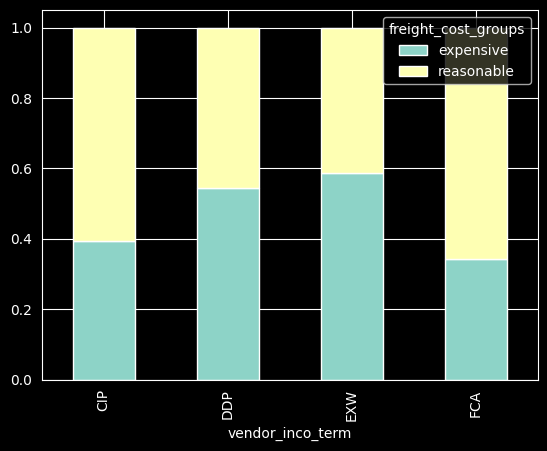

In [22]:
inco_cost_props = ship_df.groupby('vendor_inco_term')['freight_cost_groups'].value_counts(normalize=True).unstack()
inco_cost_props.plot(kind='bar', stacked=True)
plt.show()

In [23]:
expected, observed, stats = pingouin.chi2_independence(data=ship_df, x='vendor_inco_term', y='freight_cost_groups')
print(stats)
if stats['pval'].values[0] <= 0.01:
    print('Reject H_0')
else:
    print('Accept H_0')

                 test    lambda       chi2  dof          pval    cramer  \
0             pearson  1.000000  28.926261  3.0  2.320766e-06  0.170077   
1        cressie-read  0.666667  28.886281  3.0  2.366091e-06  0.169960   
2      log-likelihood  0.000000  29.008147  3.0  2.230619e-06  0.170318   
3       freeman-tukey -0.500000  29.281009  3.0  1.954700e-06  0.171117   
4  mod-log-likelihood -1.000000  29.716971  3.0  1.582790e-06  0.172386   
5              neyman -2.000000  31.120946  3.0  8.016339e-07  0.176411   

      power  
0  0.997741  
1  0.997715  
2  0.997793  
3  0.997957  
4  0.998196  
5  0.998795  
Reject H_0


---

## CHI-SQUARE TEST OF GOODNESS OF FIT
- $H_0$: the observed frequencies match the expected frequencies
- $H_A$: the observed frequencies do not match the expected frequencies
- $X^2$ test statistic:
    - $X^2 = \sum{\dfrac{(O - E)^2}{E}}$
- degrees of freedom:
    - $df = k - 1$
        - $k$ = number of categories

### &nbsp;&nbsp;&nbsp;&nbsp; •**Exercise**

---

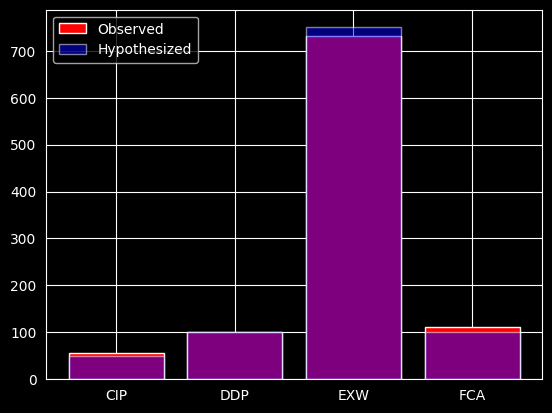

In [43]:
hypothesized = {'vendor_inco_term': ['CIP', 'DDP', 'EXW', 'FCA'], 'prop': [0.05, 0.10, 0.75, 0.10]}
hypothesized = pd.DataFrame(hypothesized)

incoterm_counts = ship_df['vendor_inco_term'].value_counts()
incoterm_counts = incoterm_counts.rename_axis('vendor_inco_term').reset_index(name='n').sort_values(by='vendor_inco_term')

n_total = len(ship_df)
hypothesized['n'] = hypothesized['prop'] * n_total


plt.bar(incoterm_counts['vendor_inco_term'], incoterm_counts['n'], color="red", label="Observed")
plt.bar(hypothesized['vendor_inco_term'], hypothesized['n'], alpha=0.5, color='blue', label="Hypothesized")

plt.legend()
plt.show()

In [45]:
gof_test = chisquare(f_obs=incoterm_counts['n'], f_exp=hypothesized['n'])
print(f'chi-square test statistic: {gof_test.statistic}\np-value: {gof_test.pvalue}')

chi-square test statistic: 2.372
p-value: 0.49886809526262577


---

## ASSUMPTIONS IN HYPOTHESIS TESTING
-